In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df = sns.load_dataset('titanic')
print(df.head())
print(df.info())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-nu

In [14]:
from sklearn.preprocessing import LabelEncoder
df = df[['survived','pclass','sex','age','fare','embarked']]

df['age'].fillna(df['age'].mean(), inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df['embarked'] = le.fit_transform(df['embarked'])

C:\Users\kedar\AppData\Local\Temp\ipykernel_11820\3682015495.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].mean(), inplace=True)
C:\Users\kedar\AppData\Local\Temp\ipykernel_11820\3682015495.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

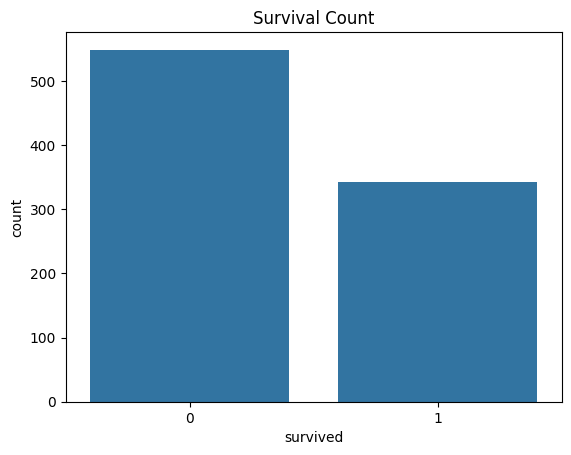

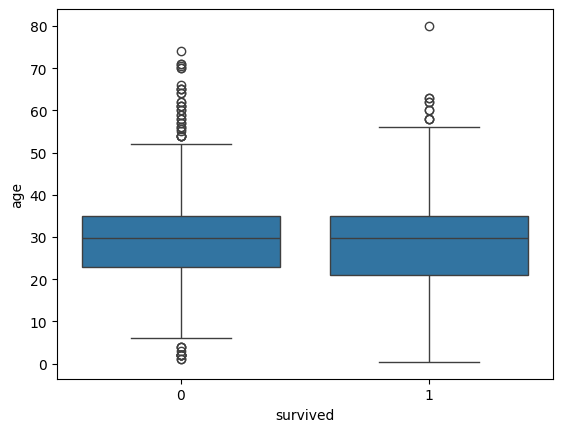

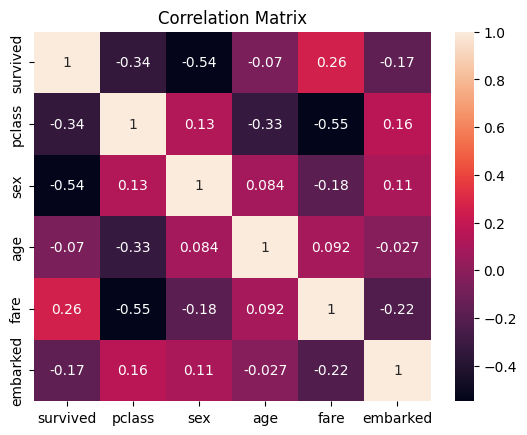

In [15]:
sns.countplot(x='survived', data=df)
plt.title("Survival Count")
plt.show()

sns.boxplot(x='survived', y='age', data=df)
plt.show()

sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

In [16]:
from sklearn.model_selection import train_test_split


X = df.drop('survived', axis=1)
y = df['survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [17]:
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.metrics import accuracy_score
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.7835820895522388


In [18]:
from sklearn.tree import DecisionTreeClassifier


bag = BaggingClassifier(DecisionTreeClassifier(), n_estimators=50)
bag.fit(X_train, y_train)

bag_pred = bag.predict(X_test)
print("Bagging Accuracy:", accuracy_score(y_test, bag_pred))

Bagging Accuracy: 0.753731343283582


In [19]:
boost = GradientBoostingClassifier()
boost.fit(X_train, y_train)

boost_pred = boost.predict(X_test)
print("Boosting Accuracy:", accuracy_score(y_test, boost_pred))

Boosting Accuracy: 0.8022388059701493


In [20]:
from sklearn.linear_model import LogisticRegression
estimators = [
    ('dt', DecisionTreeClassifier()),
    ('rf', RandomForestClassifier())
]

stack = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
stack.fit(X_train, y_train)

stack_pred = stack.predict(X_test)
print("Stacking Accuracy:", accuracy_score(y_test, stack_pred))

Stacking Accuracy: 0.7947761194029851


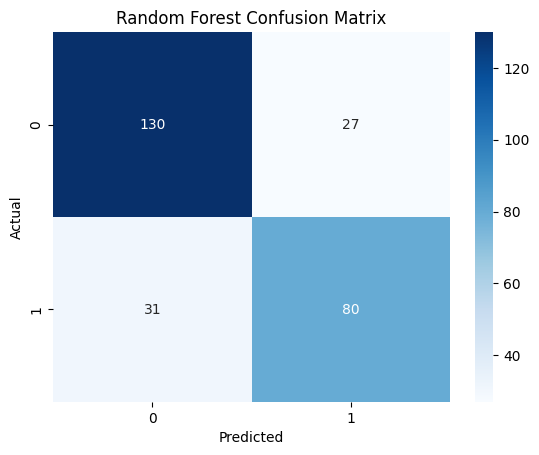

In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()